In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [17]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)

print("\nTrain columns:")
print(train_df.columns[:10])

print("\nFirst 5 rows:")
display(train_df.head())

Train shape: (42000, 785)
Test shape: (28000, 784)
Sample submission shape: (28000, 2)

Train columns:
Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8'],
      dtype='str')

First 5 rows:


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
print("Missing values in train:")
print(train_df.isnull().sum().sum())

print("\nMissing values in test:")
print(test_df.isnull().sum().sum())

print("\nDuplicate rows in train:")
print(train_df.duplicated().sum())

print("\nTarget classes:")
print(sorted(train_df["label"].unique()))

print("\nClass counts:")
print(train_df["label"].value_counts().sort_index())

Missing values in train:
0

Missing values in test:
0

Duplicate rows in train:
0

Target classes:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Class counts:
label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64


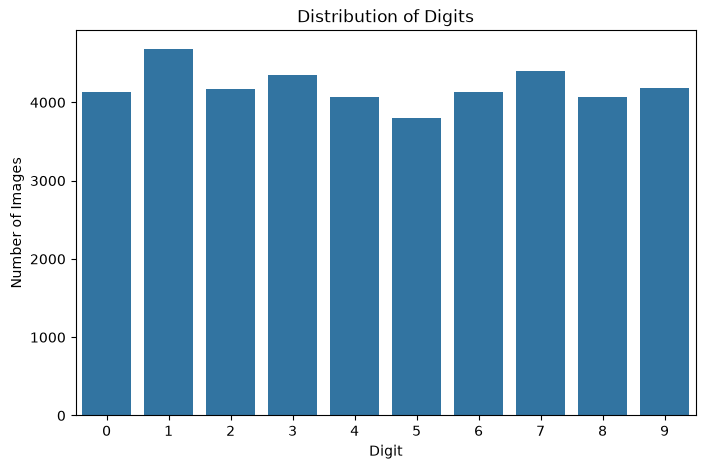

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x=train_df["label"],
    order=sorted(train_df["label"].unique())
)

plt.title("Distribution of Digits")
plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.show()

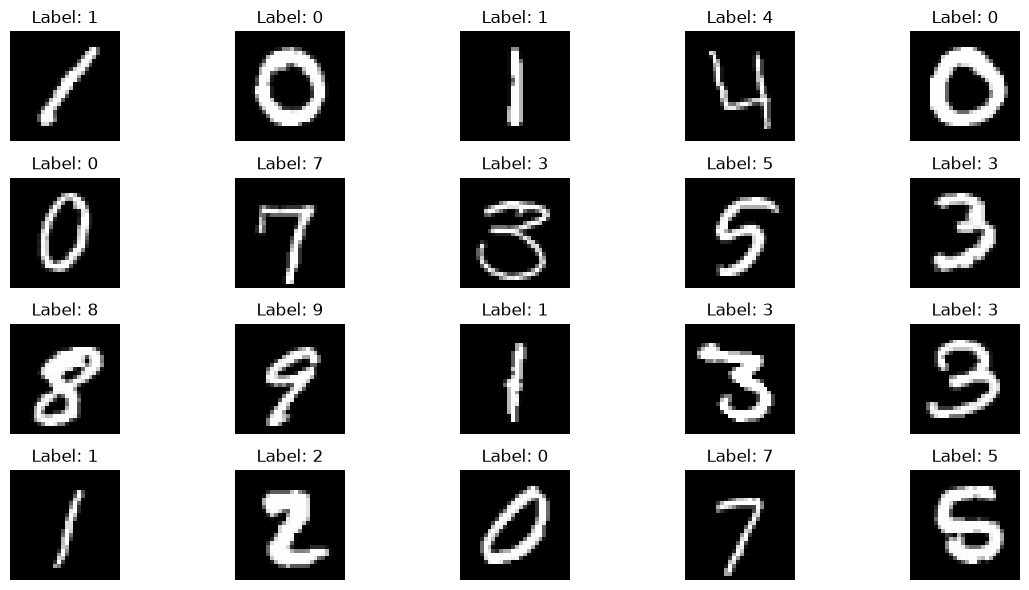

In [20]:
X_temp = train_df.drop("label", axis=1).values
y_temp = train_df["label"].values

plt.figure(figsize=(12, 6))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    image = X_temp[i].reshape(28, 28)

    plt.imshow(image, cmap="gray")
    plt.title(f"Label: {y_temp[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
pixel_values = X_temp.flatten()

print("Minimum pixel value:", pixel_values.min())
print("Maximum pixel value:", pixel_values.max())
print("Mean pixel value:", pixel_values.mean())
print("Standard deviation:", pixel_values.std())

Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 33.408911169825075
Standard deviation: 78.67773976076354


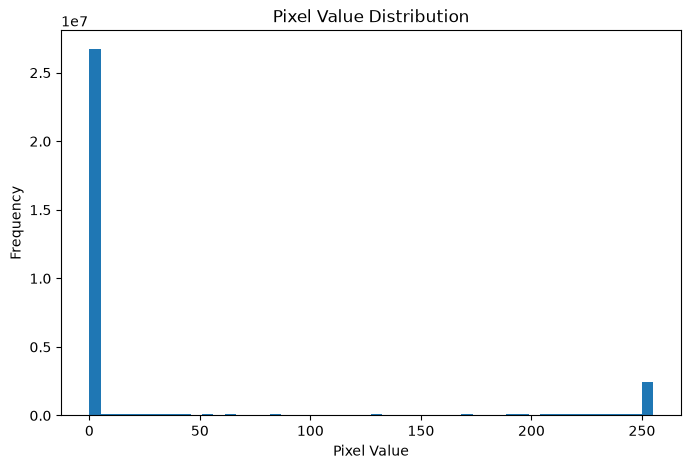

In [22]:
plt.figure(figsize=(8, 5))

plt.hist(
    pixel_values,
    bins=50
)

plt.title("Pixel Value Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.show()

In [23]:
X = train_df.drop("label", axis=1).values
y = train_df["label"].values

X_test = test_df.values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Test shape:", X_test.shape)

X shape: (42000, 784)
y shape: (42000,)
Test shape: (28000, 784)


In [24]:
X = X.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minimum:", X.min())
print("Maximum:", X.max())

Minimum: 0.0
Maximum: 1.0


In [25]:
X = X.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)
#(number of images, height, width, channels)
print("Training image shape:", X.shape)
print("Test image shape:", X_test.shape)

Training image shape: (42000, 28, 28, 1)
Test image shape: (28000, 28, 28, 1)


In [26]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: (33600, 28, 28, 1)
Validation: (8400, 28, 28, 1)


In [27]:
model = models.Sequential([
    
    layers.Input(shape=(28, 28, 1)),
    
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),
    
    layers.MaxPooling2D(
        (2, 2)
    ),
    
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    
    layers.MaxPooling2D(
        (2, 2)
    ),
    
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),
    
    layers.Flatten(),
    
    layers.Dense(
        128,
        activation="relu"
    ),
    #Create a layer containing 128 neurons.
    layers.Dropout(0.5),
    
    layers.Dense(
        10,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    #compile() prepares the model for training.
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [29]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [30]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8773 - loss: 0.3969 - val_accuracy: 0.9706 - val_loss: 0.0963 - learning_rate: 0.0010
Epoch 2/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9709 - loss: 0.1005 - val_accuracy: 0.9824 - val_loss: 0.0564 - learning_rate: 0.0010
Epoch 3/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9791 - loss: 0.0709 - val_accuracy: 0.9844 - val_loss: 0.0515 - learning_rate: 0.0010
Epoch 4/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9835 - loss: 0.0570 - val_accuracy: 0.9860 - val_loss: 0.0441 - learning_rate: 0.0010
Epoch 5/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9865 - loss: 0.0449 - val_accuracy: 0.9849 - val_loss: 0.0537 - learning_rate: 0.0010
Epoch 6/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.9890 - loss: 0.0371 - val_accuracy: 0.9864 - val_loss: 0.0491 - learning_rate: 0.0010
Epoch 7/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9929 - loss: 0.

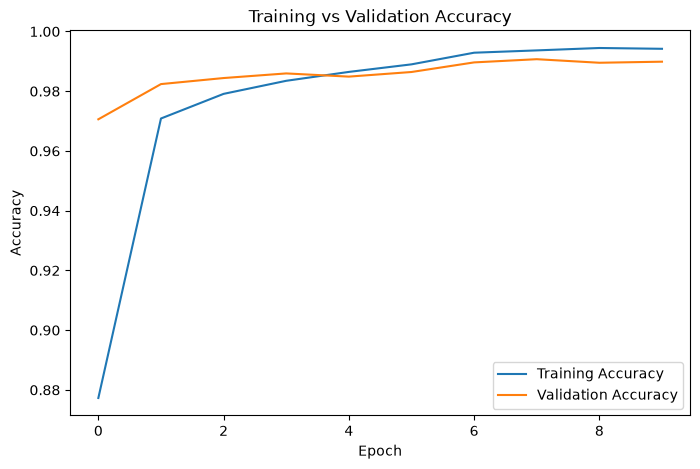

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

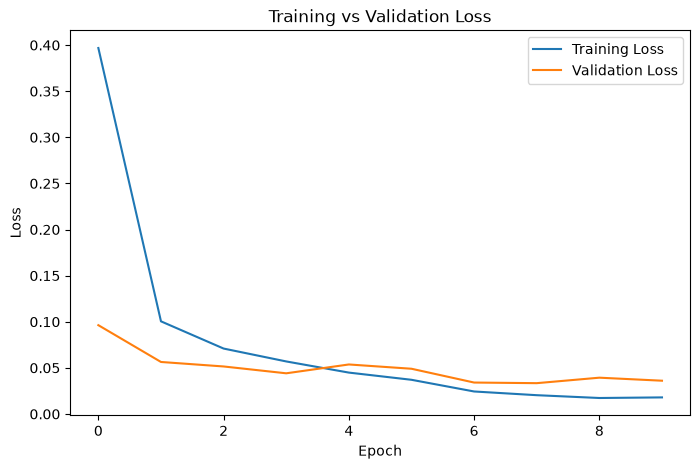

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [46]:
val_loss, val_accuracy = model.evaluate(
    X_val,
    y_val,
    verbose=0
)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

Validation Loss: 0.033418115228414536
Validation Accuracy: 0.9907143115997314


In [34]:
y_probability = model.predict(
    X_val,
    verbose=1
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

print("Predictions generated.")

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predictions generated.


In [35]:
print(
    classification_report(
        y_val,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       827
           1       1.00      1.00      1.00       937
           2       0.99      1.00      0.99       835
           3       0.99      0.98      0.99       870
           4       1.00      1.00      1.00       814
           5       0.99      0.99      0.99       759
           6       0.99      1.00      1.00       827
           7       0.99      0.99      0.99       880
           8       0.99      0.98      0.98       813
           9       0.98      0.99      0.98       838

    accuracy                           0.99      8400
   macro avg       0.99      0.99      0.99      8400
weighted avg       0.99      0.99      0.99      8400



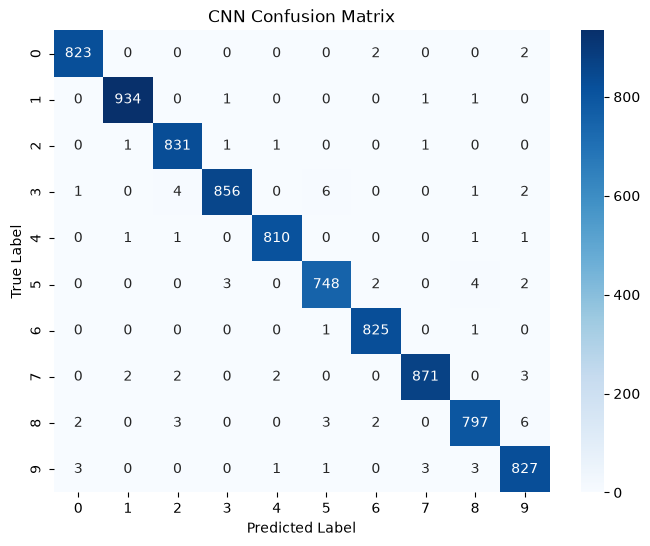

In [48]:
cm = confusion_matrix(
    y_val,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

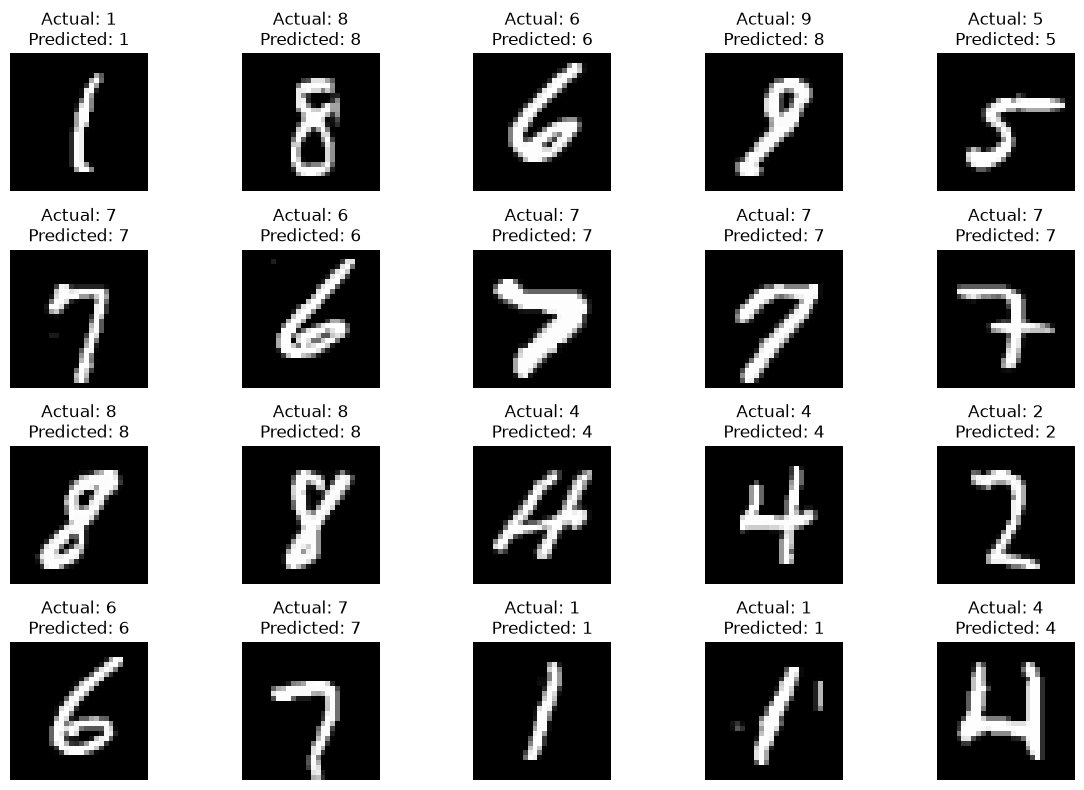

In [50]:
plt.figure(figsize=(12, 8))

for i in range(20):
    
    plt.subplot(4, 5, i + 1)
    
    plt.imshow(
        X_val[i].reshape(28, 28),
        cmap="gray"
    )
    
    plt.title(
        f"Actual: {y_val[i]}\nPredicted: {y_pred[i]}"
    )
    
    plt.axis("off")

plt.tight_layout()
plt.show()

Number of incorrect predictions: 78


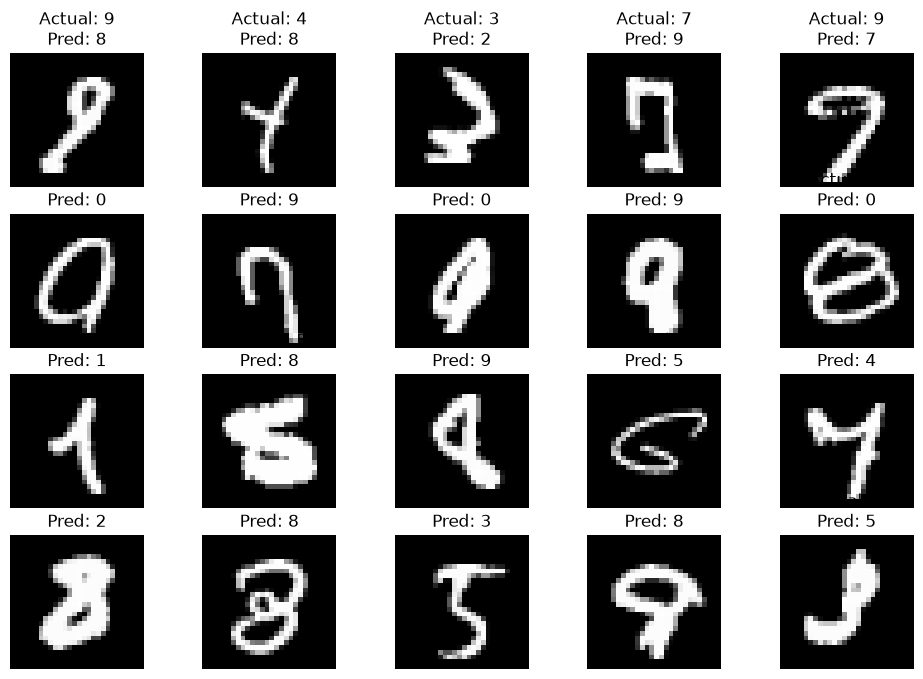

In [ ]:
wrong_indices = np.where(
    y_val != y_pred
)[0]

print("Number of incorrect predictions:", len(wrong_indices))

plt.figure(figsize=(12, 8))

for i in range(min(20, len(wrong_indices))):
    
    index = wrong_indices[i]
    
    plt.subplot(4, 5, i + 1)
    
    plt.imshow(
        X_val[index].reshape(28, 28),
        cmap="gray"
    )
    
    plt.title(
        f"Actual: {y_val[index]}\nPred: {y_pred[index]}"
    )
    
    plt.axis("off")

plt.tight_layout()
plt.show()

In [39]:
model.save("digit_cnn.keras")

print("Model saved successfully.")

Model saved successfully.


In [ ]:
test_probability = model.predict(
    X_test,
    verbose=1
)

test_predictions = np.argmax(
    test_probability,
    axis=1
)

print("Test predictions generated.")

875/875 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Test predictions generated.


In [41]:
print(sample_submission.head())
print(sample_submission.columns)

   ImageId  Label
0        1      0
1        2      0
2        3      0
3        4      0
4        5      0
Index(['ImageId', 'Label'], dtype='str')


In [56]:
submission = sample_submission.copy()

submission["Label"] = test_predictions

submission.to_csv(
    "submission.csv",
    index=False
)

print("submission.csv created.")
display(submission.head())

submission.csv created.


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


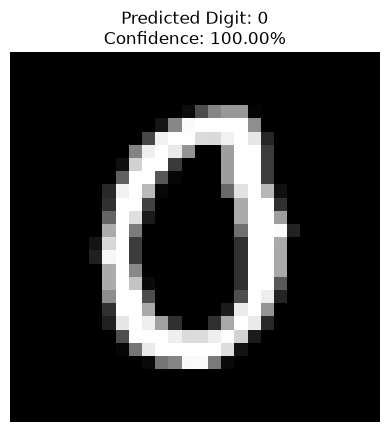

In [58]:
index = 100

image = X_test[index]

prediction_probability = model.predict(
    image.reshape(1, 28, 28, 1),
    verbose=0
)

prediction = np.argmax(
    prediction_probability
)

confidence = np.max(
    prediction_probability
)

plt.imshow(
    image.reshape(28, 28),
    cmap="gray"
)

plt.title(
    f"Predicted Digit: {prediction}\n"
    f"Confidence: {confidence:.2%}"
)

plt.axis("off")
plt.show()

In [1]:
import tensorflow as tf